In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
COLORS = {"dense": "#E24B4A", "medium": "#EF9F27", "sparse": "#1D9E75"}
RIG_COLORS = {"det": "#378ADD", "fuzzy": "#9F77DD"}

In [4]:
df = pd.read_csv('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/targeted_sdp_benchmark_collected.csv')

In [5]:
df.head(20)

,Network,N_Nodes,Target_Bucket,Target_Node,Target_Value,Exact_SDP,Exact_Time_sec,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,Absolute_Error
0,voting,17,0.5,Class,republican,0.534074,0.004503,0.526407,0.000536,2.654223,7.666511e-03
1,voting,17,0.6,Class,republican,0.644603,0.004499,0.650143,0.000505,2.578761,5.540025e-03
2,voting,17,0.7,Class,republican,0.652704,0.004866,0.641957,0.000488,2.685983,1.074651e-02
3,voting,17,0.8,Class,republican,0.790059,0.005807,0.780293,0.000547,2.632378,9.766015e-03
4,voting,17,0.9,Class,republican,0.864120,0.004467,0.863643,0.000260,2.578115,4.767049e-04
5,voting,17,1.0,Class,republican,0.975740,0.004742,0.974514,0.000028,2.593402,1.225516e-03
6,chess,36,0.4,skach,t,0.426748,0.048160,0.427971,0.000578,3.299545,1.223340e-03
7,chess,36,0.5,skach,t,0.540559,0.020667,0.554829,0.000300,3.291807,1.426997e-02
8,chess,36,0.6,skach,t,0.607173,0.009554,0.599371,0.000607,3.841575,7.801786e-03
9,chess,36,0.7,skach,t,0.680555,0.028013,0.665571,0.000482,3.667373,1.498381e-02


In [6]:
COLORS = {}
# pick a different color for each number of nodes
for num_nodes in df["N_Nodes"].unique():
    COLORS[num_nodes] = np.random.rand(3,)

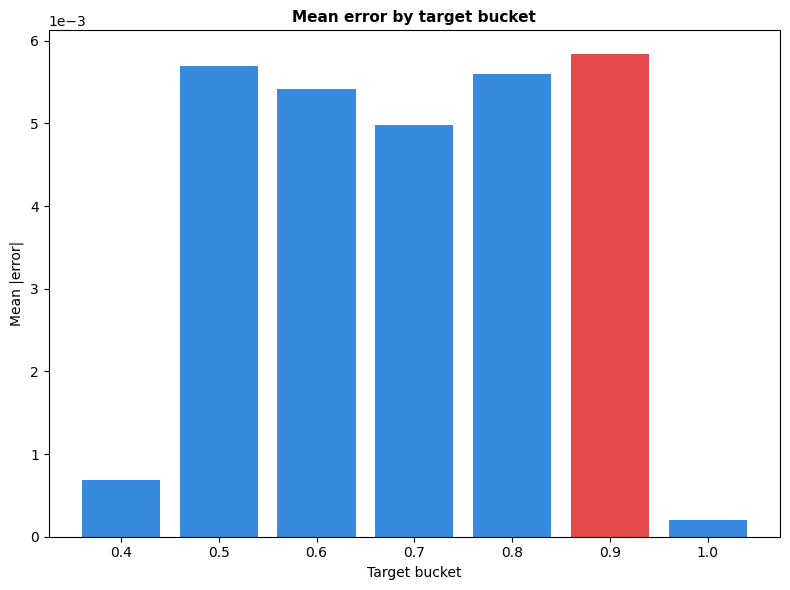

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

g_bkt = df.groupby("Target_Bucket")["Absolute_Error"].mean()
bar_colors = ["#E24B4A" if v == g_bkt.max() else "#378ADD" for v in g_bkt.values]
ax.bar([str(b) for b in g_bkt.index], g_bkt.values,
       color=bar_colors, edgecolor="none")

ax.set_title("Mean error by target bucket", fontsize=11, fontweight="bold")
ax.set_xlabel("Target bucket")
ax.set_ylabel("Mean |error|")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("benchmark_mean_error_by_target_bucket.png", dpi=150, bbox_inches="tight")
plt.show()

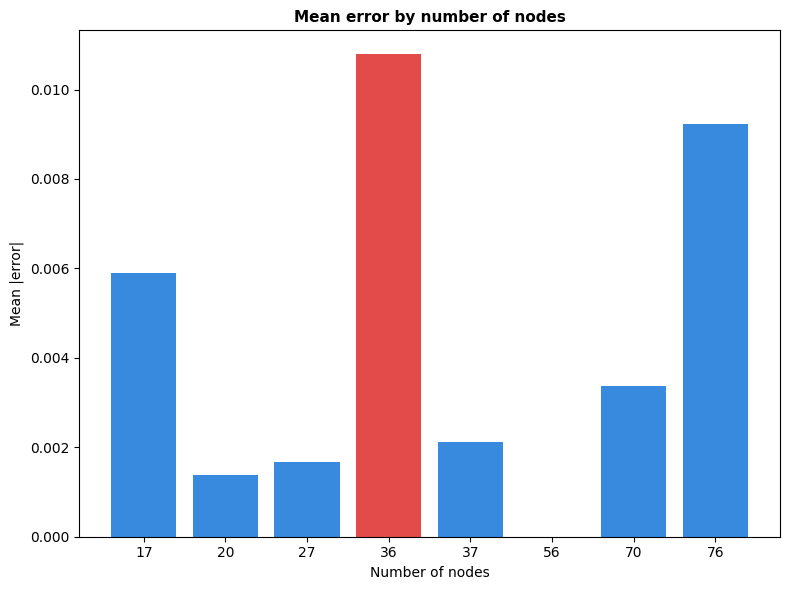

In [8]:
# error by number of nodes

fig, ax = plt.subplots(figsize=(8, 6))
g_nodes = df.groupby("N_Nodes")["Absolute_Error"].mean()
bar_colors = ["#E24B4A" if v == g_nodes.max() else "#378ADD" for v in g_nodes.values]
ax.bar([str(b) for b in g_nodes.index], g_nodes.values,
       color=bar_colors, edgecolor="none")
ax.set_title("Mean error by number of nodes", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Mean |error|")

plt.tight_layout()
plt.savefig("benchmark_mean_error_by_num_nodes.png", dpi=150, bbox_inches="tight")
plt.show()

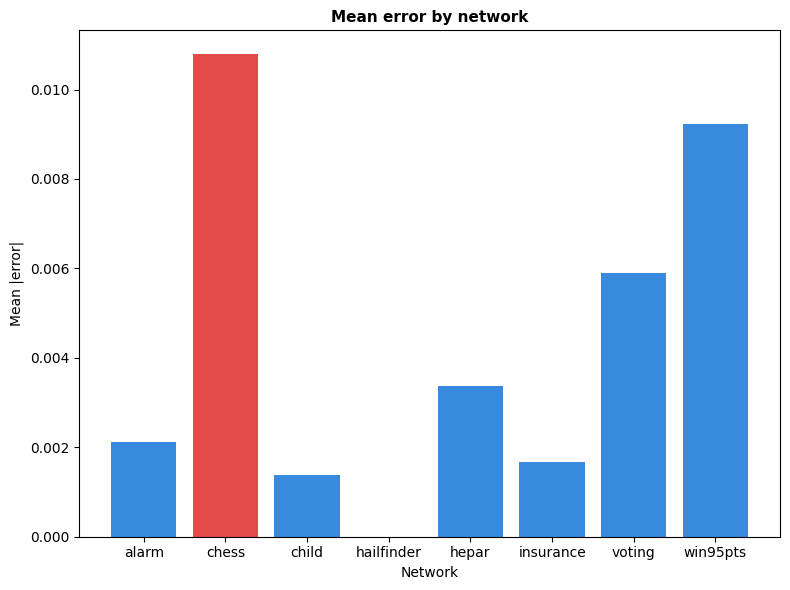

In [10]:
# error by network name
fig, ax = plt.subplots(figsize=(8, 6))
g_name = df.groupby("Network")["Absolute_Error"].mean()
bar_colors = ["#E24B4A" if v == g_name.max() else "#378ADD" for v in g_name.values]
ax.bar(g_name.index, g_name.values,
       color=bar_colors, edgecolor="none")
ax.set_title("Mean error by network", fontsize=11, fontweight="bold")
ax.set_xlabel("Network")
ax.set_ylabel("Mean |error|")
plt.tight_layout()
plt.savefig("benchmark_mean_error_by_network.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
bn_entropies = pd.read_csv('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/bn_entropies.csv')
bn_entropies = bn_entropies.rename(columns={"Model": "Network"})
bn_entropies.head()

,Network,Entropy (nats)
0,voting,8.408815
1,chess,14.331518
2,alarm,10.437962
3,child,12.195767
4,insurance,13.063305


In [27]:
# plot error by entropy

merged = pd.merge(df, bn_entropies, on="Network")
merged.head()



,Network,N_Nodes,Target_Bucket,Target_Node,Target_Value,Exact_SDP,Exact_Time_sec,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,Absolute_Error,Entropy (nats)
0,voting,17,0.5,Class,republican,0.534074,0.004503,0.526407,0.000536,2.654223,0.007667,8.408815
1,voting,17,0.6,Class,republican,0.644603,0.004499,0.650143,0.000505,2.578761,0.005540,8.408815
2,voting,17,0.7,Class,republican,0.652704,0.004866,0.641957,0.000488,2.685983,0.010747,8.408815
3,voting,17,0.8,Class,republican,0.790059,0.005807,0.780293,0.000547,2.632378,0.009766,8.408815
4,voting,17,0.9,Class,republican,0.864120,0.004467,0.863643,0.000260,2.578115,0.000477,8.408815


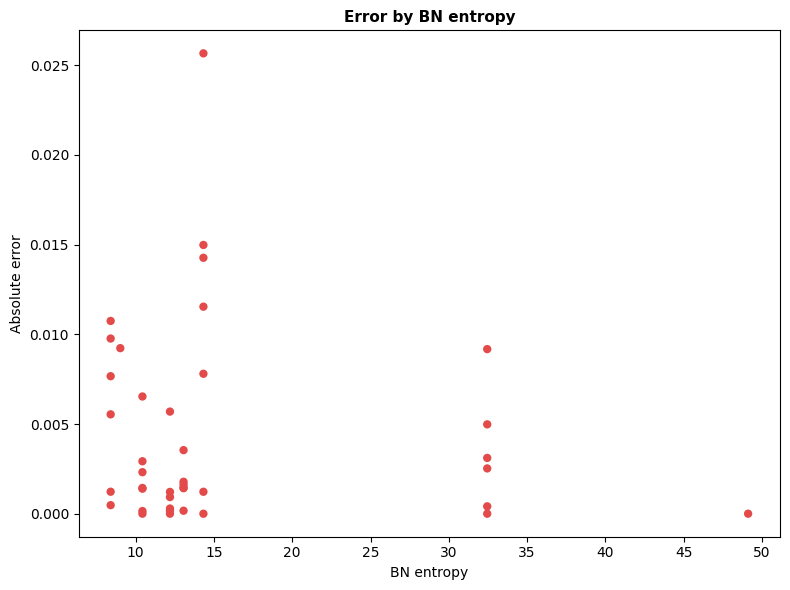

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["Entropy (nats)"], merged["Absolute_Error"], color="#E24B4A", edgecolor="none")
ax.set_title("Error by BN entropy", fontsize=11, fontweight="bold")
ax.set_xlabel("BN entropy")
ax.set_ylabel("Absolute error")
plt.tight_layout()
plt.savefig("benchmark_error_by_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

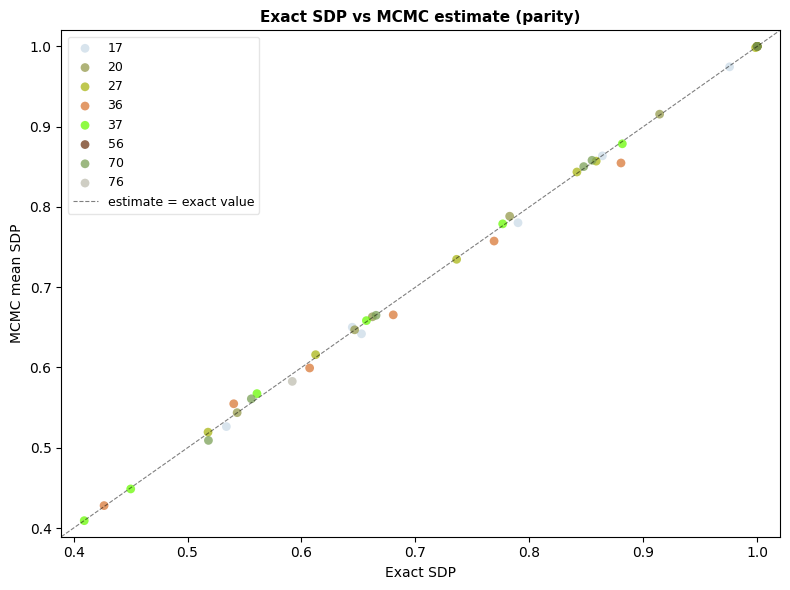

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for num_nodes, grp in df.groupby("N_Nodes"):
    ax.scatter(grp["Exact_SDP"], grp["MCMC_Mean_SDP"],
               label=num_nodes, color=COLORS[num_nodes], alpha=0.75, s=40, edgecolors="none")

lims = [df[["Exact_SDP", "MCMC_Mean_SDP"]].min().min() - 0.02,
        df[["Exact_SDP", "MCMC_Mean_SDP"]].max().max() + 0.02]

ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5, label="estimate = exact value")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Exact SDP vs MCMC estimate (parity)", fontsize=11, fontweight="bold")
ax.set_xlabel("Exact SDP")
ax.set_ylabel("MCMC mean SDP")
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("benchmark_exact_vs_mcmc_parity.png", dpi=150, bbox_inches="tight")
plt.show()